# 6.0 Baseline


## Imports


In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from recruit_restaurant_visitor_forecasting.config.feature_names import agg_exp_col
from recruit_restaurant_visitor_forecasting.config.features import (
    DAY_OF_WEEK_COL, VISITORS_DOW, MEAN_PREF
)
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

from recruit_restaurant_visitor_forecasting.config.config import (
    VISIT_DATE_COL, AIR_RESTAURANT_ID_COL, PROCESSED_DATA_DIR, MODELS_DIR
)
from recruit_restaurant_visitor_forecasting.config.modeling import TEST_SIZE
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.modeling.pipeline import MeanBaseline
from recruit_restaurant_visitor_forecasting.plots import plot_actual_pred
from recruit_restaurant_visitor_forecasting.utils import merge_daily_pred, get_format

2026-05-11 13:31:03.882 | INFO     | recruit_restaurant_visitor_forecasting.config.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
MODEL_NAME = "baseline"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

Features shape: (271224, 103)
Labels shape: (271224,)


In [4]:
features = prepare_features(features)

labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [5]:
X = features
y = labels

In [6]:
X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-03-08 00:00:00
Test set dates: 2017-03-09 00:00:00 to 2017-04-22 00:00:00


## Model

In [7]:
VISITORS_DOW_MEAN_COL = agg_exp_col(VISITORS_DOW, MEAN_PREF)

In [8]:
model = MeanBaseline(AIR_RESTAURANT_ID_COL, VISIT_DATE_COL, DAY_OF_WEEK_COL, VISITORS_DOW_MEAN_COL)
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)

In [9]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")


Test set metrics:
RMSLE: 0.8756
MAE:  7.8844
R2:   0.5065


## Graphs

### Visitors per day: actual vs predicted

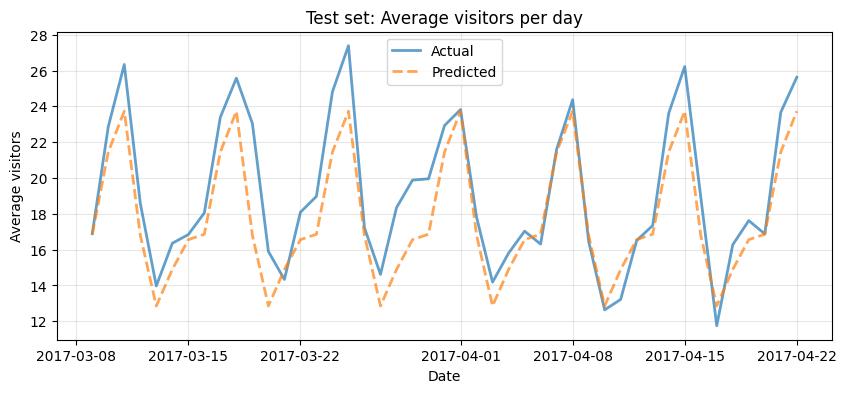

In [10]:
test_daily = merge_daily_pred(test_dates, y_test, pd.Series(y_test_pred))
fig, axes = plt.subplots(figsize=(10, 4))
plot_actual_pred(axes, test_daily, "Test set")

plt.show()

In [11]:
test_features = pd.read_csv(PROCESSED_DATA_DIR / "test_features.csv")
test_features = prepare_features(test_features)
test_features = test_features.reset_index(drop=True)

In [12]:
model.fit(X, y)
test_labels = model.predict(test_features)

In [13]:
labels_format = get_format(test_features, pd.Series(test_labels))
labels_format.to_csv(PROCESSED_DATA_DIR / "test_labels.csv", index=False)

In [14]:
joblib.dump(model, MODEL_PATH)

['D:\\mentoring_program\\models\\baseline_model.pkl']